<a href="https://colab.research.google.com/github/rifkiahmadrumatella/RIFKI-165-TUGAS-2-MOBILE/blob/main/LSTM_Sentiment_Analysis_MBG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Sentimen Dataset MBG Menggunakan Deep Learning (LSTM)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Import Library

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Bidirectional,
    SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping


## 2. Load Dataset

In [ ]:
DATA_PATH = "/content/drive/MyDrive/MBG/MBG-label.csv"

df = pd.read_csv(DATA_PATH)

print("Shape Dataset:", df.shape)
display(df.head())
print(df.columns)


Shape Dataset: (4968, 2)


,comment,sentiment
0,"pusing denger bahas pemerintah, ga ada bener nya",negatif
1,Anak gue baru tk dpt jg mbg buat apaan cba.. u...,netral
2,Program ini sudah ada di jaman Suharto waktu s...,netral
3,"Aku gak setuju bukan karena program nya gagal,...",negatif
4,Indonesia saya perhatikan melaksanakan proyek...,negatif


Index(['comment', 'sentiment'], dtype='object')


## 3. Data Cleaning

In [ ]:
print(df.isnull().sum())

df = df.dropna(subset=["comment", "sentiment"])
df = df.drop_duplicates(subset=["comment"])

print("Jumlah data setelah cleaning:", len(df))


comment      0
sentiment    0
dtype: int64
Jumlah data setelah cleaning: 4899


## 4. Label Encoding

In [ ]:
df["sentiment"] = df["sentiment"].astype(str).str.lower().str.strip()

label_mapping = {
    "negatif": 0,
    "netral": 1,
    "positif": 2
}

df["label"] = df["sentiment"].map(label_mapping)

print(df["label"].isnull().sum())

df = df.dropna(subset=["label"])
df["label"] = df["label"].astype(int)

display(df[["sentiment", "label"]].head())


0


,sentiment,label
0,negatif,0
1,netral,1
2,netral,1
3,negatif,0
4,negatif,0


## 5. Text Preprocessing

In [ ]:
def clean_text(text):
    text = str(text).lower()

    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["text_clean"] = df["comment"].apply(clean_text)

display(df[["comment", "text_clean"]].head())


,comment,text_clean
0,"pusing denger bahas pemerintah, ga ada bener nya",pusing denger bahas pemerintah ga ada bener nya
1,Anak gue baru tk dpt jg mbg buat apaan cba.. u...,anak gue baru tk dpt jg mbg buat apaan cba uju...
2,Program ini sudah ada di jaman Suharto waktu s...,program ini sudah ada di jaman suharto waktu s...
3,"Aku gak setuju bukan karena program nya gagal,...",aku gak setuju bukan karena program nya gagal ...
4,Indonesia saya perhatikan melaksanakan proyek...,indonesia saya perhatikan melaksanakan proyek ...


## 6. Split Data Training dan Testing

In [ ]:
X = df["text_clean"].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah Data Train:", len(X_train))
print("Jumlah Data Test :", len(X_test))


Jumlah Data Train: 3919
Jumlah Data Test : 980


## 7. Tokenizing dan Padding

In [ ]:
VOCAB_SIZE = 20000
MAX_LEN = 60
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN
)

tokenizer.fit_on_texts(X_train)

train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(
    train_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    test_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Shape X_train:", X_train_pad.shape)
print("Shape X_test :", X_test_pad.shape)


Shape X_train: (3919, 60)
Shape X_test : (980, 60)


## 8. Membangun Model Deep Learning (LSTM)

In [ ]:
EMBED_DIM = 128

model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        input_length=MAX_LEN
    ),

    SpatialDropout1D(0.3),

    Bidirectional(
        LSTM(
            128,
            dropout=0.3,
            recurrent_dropout=0.3,
            return_sequences=False
        )
    ),

    Dense(64, activation="relu"),
    Dropout(0.5),

    Dense(3, activation="softmax")
])

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 9. Training Model

In [ ]:
EPOCHS = 10
BATCH_SIZE = 64

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 19s 276ms/step - accuracy: 0.6163 - loss: 0.8465 - val_accuracy: 0.6531 - val_loss: 0.7631
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 258ms/step - accuracy: 0.6976 - loss: 0.7161 - val_accuracy: 0.7015 - val_loss: 0.6756
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 21s 257ms/step - accuracy: 0.8147 - loss: 0.5259 - val_accuracy: 0.7742 - val_loss: 0.5900
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 20s 256ms/step - accuracy: 0.8839 - loss: 0.3531 - val_accuracy: 0.7768 - val_loss: 0.6140
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 21s 255ms/step - accuracy: 0.9110 - loss: 0.2469 - val_accuracy: 0.7666 - val_loss: 0.7005
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 250ms/step - accuracy: 0.9254 - loss: 0.1913 - val_accuracy: 0.7832 - val_loss: 0.7165


## 10. Visualisasi Hasil Training

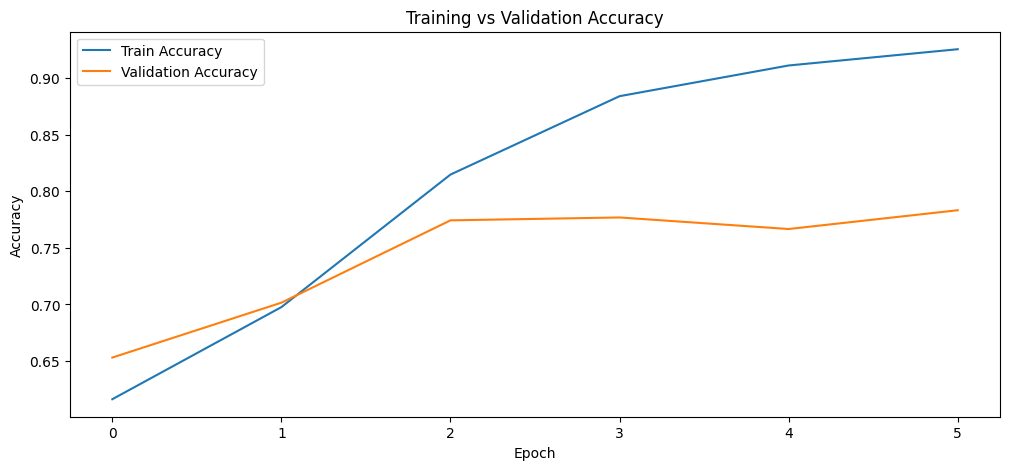

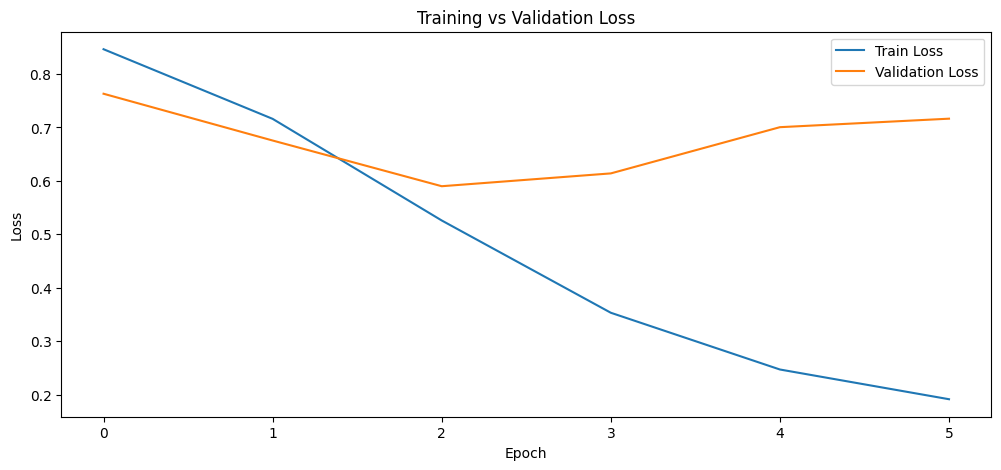

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


## 11. Testing dan Evaluasi Model

In [ ]:
loss, accuracy = model.evaluate(X_test_pad, y_test)

print("\nTest Loss     :", loss)
print("Test Accuracy :", accuracy)


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7531 - loss: 0.6497

Test Loss     : 0.6496832966804504
Test Accuracy : 0.7530612349510193


## 12. Prediksi Data Testing

In [ ]:
pred_prob = model.predict(X_test_pad)

pred_label = np.argmax(pred_prob, axis=1)

print(classification_report(
    y_test,
    pred_label,
    target_names=['Negatif', 'Netral', 'Positif']
))


31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step
              precision    recall  f1-score   support

     Negatif       0.77      0.85      0.81       495
      Netral       0.73      0.73      0.73       432
     Positif       0.00      0.00      0.00        53

    accuracy                           0.75       980
   macro avg       0.50      0.53      0.51       980
weighted avg       0.71      0.75      0.73       980



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 13. Confusion Matrix

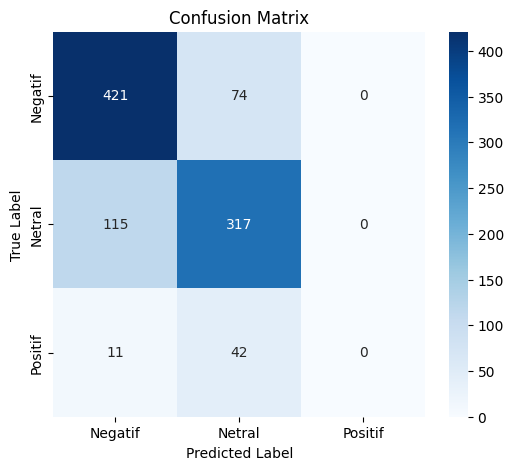

In [ ]:
cm = confusion_matrix(y_test, pred_label)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negatif', 'Netral', 'Positif'],
    yticklabels=['Negatif', 'Netral', 'Positif']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


## 14. Testing Manual

In [ ]:
def predict_sentiment(text):
    text = clean_text(text)

    seq = tokenizer.texts_to_sequences([text])

    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post')

    pred = model.predict(padded)
    label = np.argmax(pred)

    mapping = {
        0: 'Negatif',
        1: 'Netral',
        2: 'Positif'
    }

    return mapping[label]

sample_text = "Program MBG sangat membantu masyarakat"

hasil = predict_sentiment(sample_text)

print("Kalimat:", sample_text)
print("Prediksi:", hasil)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Kalimat: Program MBG sangat membantu masyarakat
Prediksi: Negatif


## 15. Save Model

In [ ]:
model.save("/content/drive/MyDrive/MBG/model_lstm_sentiment.keras")

print("Model berhasil disimpan")

Model berhasil disimpan
